In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder

In [14]:
df = pd.read_csv("HR_comma_sep.csv")

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [16]:
df.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [17]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [19]:
categories = [["low", "medium", "high"]]
oe = OrdinalEncoder(categories = categories)
df["salary"] = oe.fit_transform(df[["salary"]]).astype(int)

In [24]:
le = LabelEncoder()
df["Department"] = le.fit_transform(df["Department"])

In [25]:
for number, department in enumerate(le.classes_):
    print(number, department)

0 IT
1 RandD
2 accounting
3 hr
4 management
5 marketing
6 product_mng
7 sales
8 support
9 technical


#Insights

1. Satisfaction_level has a strong negative correlation with left (-0.39), meaning the less satisfied employees are, the more likely they are to leave.

2. Work_accident and left have a negative correlation (-0.15), suggesting employees who had accidents were slightly less likely to leave.

3. Higher salaries slightly reduce the likelihood of leaving.(-0.16)

4. Time spend in a company slightly increases number of leaving(0.14)

<Axes: >

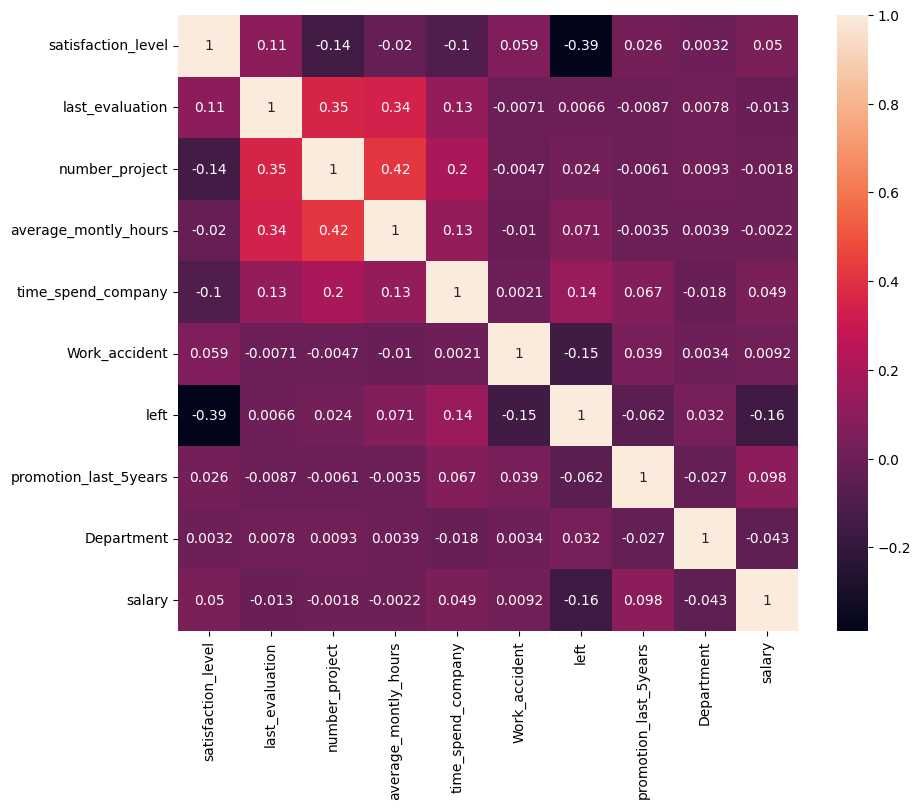

In [26]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include=np.number).corr(),annot=True)

In [34]:
df1 = df["left"].groupby(df["Department"]).sum()
df2 = df["left"].groupby(df["Department"]).count()
print(df1 / df2 * 100)

Department
0    22.249389
1    15.374841
2    26.597132
3    29.093369
4    14.444444
5    23.659674
6    21.951220
7    24.492754
8    24.899058
9    25.625000
Name: left, dtype: float64


# Model building


In [36]:
subdf = df[["satisfaction_level", "Work_accident", "salary", "time_spend_company"]]
subdf

,satisfaction_level,Work_accident,salary,time_spend_company
0,0.38,0,0,3
1,0.80,0,1,6
2,0.11,0,1,4
3,0.72,0,0,5
4,0.37,0,0,3
...,...,...,...,...
14994,0.40,0,0,3
14995,0.37,0,0,3
14996,0.37,0,0,3
14997,0.11,0,0,4


In [37]:
x_train, x_test, y_train, y_test = train_test_split(subdf, df["left"], test_size=0.2, random_state=42)

In [53]:
model = LogisticRegression()

In [58]:
model.fit(x_train, y_train)

LogisticRegression()

In [60]:
model.score(x_test, y_test)

0.761